In [10]:
#"Lab3"
#"By Shreyas More"

#Step 1: Import Libraries (wine)



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the Wine dataset
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print("Dataset shape:", X.shape)
print("\nFeature names:")
print(list(X.columns))
print("\nFirst five rows:")
display(X.head())

print("\nClass distribution:")
print(pd.Series(y).value_counts().sort_index())



Dataset shape: (178, 13)

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

First five rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Class distribution:
0    59
1    71
2    48
Name: count, dtype: int64


In [11]:
#Do Basic Data Exploration

print("Descriptive statistics:")
display(X.describe().T)

print("\nMissing values:")
print(X.isnull().sum().sum())

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00



Missing values:
0


In [12]:
#Step 2:Implement K-CLustering

# Standardize using z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=wine.feature_names)

print("Mean of standardized features (approximately 0):")
print(X_scaled_df.mean().round(4))

print("\nStandard deviation of standardized features (approximately 1):")
print(X_scaled_df.std(ddof=0).round(4))

# K-Means with k = 3
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=RANDOM_STATE,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Performance metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Results")
print("----------------")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_ari:.4f}")
print("\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nCentroid matrix shape:", kmeans.cluster_centers_.shape)



Mean of standardized features (approximately 0):
alcohol                        -0.0
malic_acid                     -0.0
ash                            -0.0
alcalinity_of_ash              -0.0
magnesium                      -0.0
total_phenols                   0.0
flavanoids                     -0.0
nonflavanoid_phenols            0.0
proanthocyanins                -0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

Standard deviation of standardized features (approximately 1):
alcohol                         1.0
malic_acid                      1.0
ash                             1.0
alcalinity_of_ash               1.0
magnesium                       1.0
total_phenols                   1.0
flavanoids                      1.0
nonflavanoid_phenols            1.0
proanthocyanins                 1.0
color_intensity                 1.0
hue                             1.0
od280/od

In [13]:
#STEP 3 


def kmedoids_pam(X, n_clusters=3, max_iter=100, random_state=42):
    """Simple PAM-style K-Medoids implementation using Euclidean distance."""
    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]

    # Initial medoids are distinct observations
    medoids = rng.choice(n_samples, size=n_clusters, replace=False)

    # Full pairwise distance matrix
    diff = X[:, None, :] - X[None, :, :]
    distances = np.sqrt(np.sum(diff ** 2, axis=2))

    def assign(medoids):
        d = distances[:, medoids]
        labels = np.argmin(d, axis=1)
        cost = np.sum(np.min(d, axis=1))
        return labels, cost

    labels, current_cost = assign(medoids)

    for _ in range(max_iter):
        improved = False

        # Try swapping each medoid with each non-medoid
        for medoid_position in range(n_clusters):
            non_medoids = [i for i in range(n_samples) if i not in medoids]

            best_swap = None
            best_cost = current_cost

            for candidate in non_medoids:
                trial_medoids = medoids.copy()
                trial_medoids[medoid_position] = candidate

                _, trial_cost = assign(trial_medoids)

                if trial_cost < best_cost - 1e-10:
                    best_cost = trial_cost
                    best_swap = candidate

            if best_swap is not None:
                medoids[medoid_position] = best_swap
                current_cost = best_cost
                labels, _ = assign(medoids)
                improved = True

        if not improved:
            break

    labels, current_cost = assign(medoids)
    return medoids, labels, current_cost


# Run K-Medoids
medoid_indices, kmedoids_labels, kmedoids_cost = kmedoids_pam(
    X_scaled,
    n_clusters=3,
    max_iter=100,
    random_state=RANDOM_STATE
)

kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Results")
print("------------------")
print(f"Silhouette Score: {kmedoids_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmedoids_ari:.4f}")
print(f"Total clustering cost: {kmedoids_cost:.4f}")

print("\nCluster sizes:")
print(pd.Series(kmedoids_labels).value_counts().sort_index())

print("\nMedoid observation indices:")
print(medoid_indices)

print("\nMedoid feature values (standardized):")
display(pd.DataFrame(
    X_scaled[medoid_indices],
    columns=wine.feature_names
))

K-Medoids Results
------------------
Silhouette Score: 0.2676
Adjusted Rand Index (ARI): 0.7411
Total clustering cost: 500.9292

Cluster sizes:
0    55
1    74
2    49
Name: count, dtype: int64

Medoid observation indices:
[106  35 148]

Medoid feature values (standardized):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,-0.927212,-0.544297,-0.901103,-0.148624,-1.386122,-1.033684,0.000733,0.065639,0.068508,-0.717240,0.186684,0.788587,-0.754385
1,0.592164,-0.472483,0.158946,0.301803,0.018145,0.648764,0.954502,-0.820719,0.471488,0.018129,0.362177,1.212320,0.551257
2,0.394521,0.811175,0.049285,0.602088,-0.543562,-0.585031,-1.274305,0.710264,-0.597284,1.454261,-1.787619,-1.400699,-0.308556


Variance explained by PC1: 36.20%
Variance explained by PC2: 19.21%
Total variance explained by two PCs: 55.41%


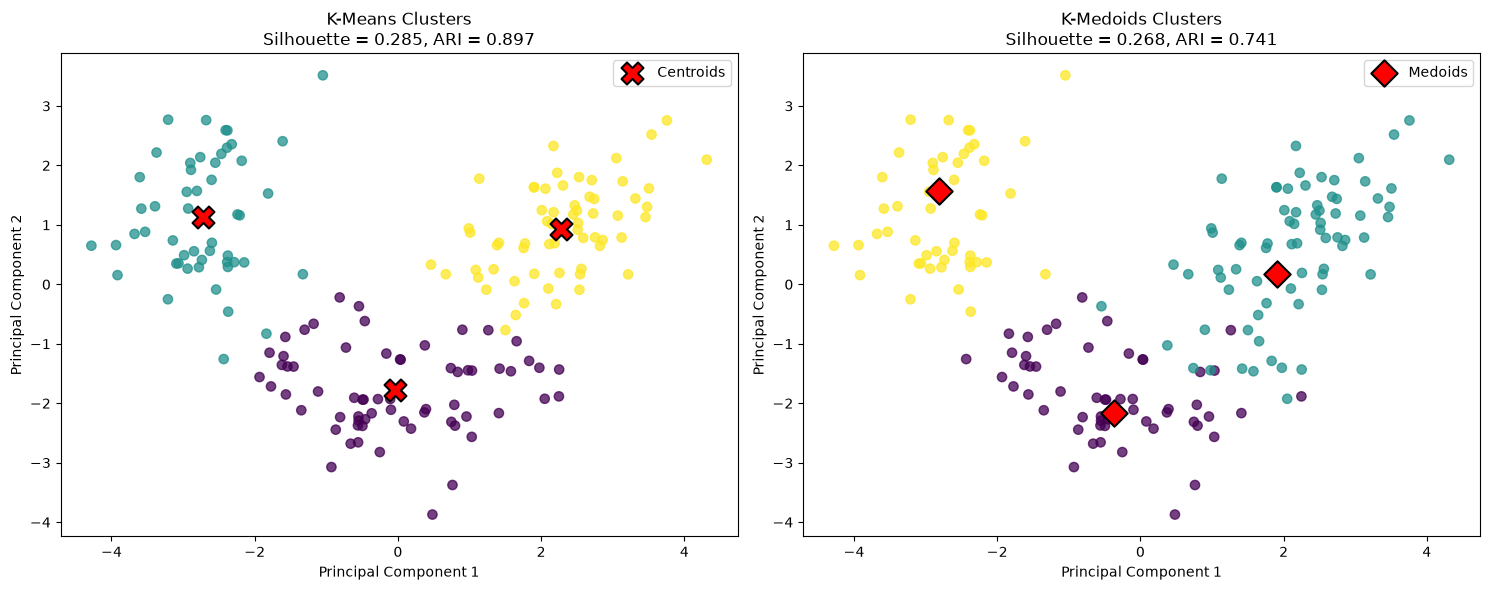

,Algorithm,Silhouette Score,Adjusted Rand Index (ARI)
0,K-Means,0.2849,0.8975
1,K-Medoids,0.2676,0.7411


In [ ]:
#STEP 4

# PCA projection to two dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Project K-Means centroids into PCA space
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)

# Project K-Medoids observations into PCA space
kmedoids_centers_pca = X_pca[medoid_indices]

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained by two PCs: {pca.explained_variance_ratio_.sum():.2%}")


# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means
axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=45,
    alpha=0.75
)
axes[0].scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    marker="X",
    s=250,
    c="red",
    edgecolor="black",
    linewidth=1.5,
    label="Centroids"
)
axes[0].set_title(
    f"K-Means Clusters\nSilhouette = {kmeans_silhouette:.3f}, ARI = {kmeans_ari:.3f}"
)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

# K-Medoids
axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmedoids_labels,
    cmap="viridis",
    s=45,
    alpha=0.75
)
axes[1].scatter(
    kmedoids_centers_pca[:, 0],
    kmedoids_centers_pca[:, 1],
    marker="D",
    s=180,
    c="red",
    edgecolor="black",
    linewidth=1.5,
    label="Medoids"
)
axes[1].set_title(
    f"K-Medoids Clusters\nSilhouette = {kmedoids_silhouette:.3f}, ARI = {kmedoids_ari:.3f}"
)
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend()

plt.tight_layout()
plt.show()


# Numerical comparison table
results = pd.DataFrame({
    "Algorithm": ["K-Means", "K-Medoids"],
    "Silhouette Score": [kmeans_silhouette, kmedoids_silhouette],
    "Adjusted Rand Index (ARI)": [kmeans_ari, kmedoids_ari]
})

display(results.round(4))
